In [15]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

CURRENT = Path.cwd()

# Si el notebook corre desde .../Repositorio_APIS/notebooks
PROJECT_ROOT = CURRENT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "global_crisis_data.csv"

df = pd.read_csv(DATA_PATH)

print("Carpeta actual:", CURRENT)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("Ruta usada:", DATA_PATH)
print("Dimensión base original:", df.shape)

df.head()

Carpeta actual: c:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\notebooks
PROJECT_ROOT: c:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS
Ruta usada: c:\Users\edwar\Desktop\Estadistica 2026-1\Series De tiempo\Segundo semestre\Repositorio_APIS\data\raw\global_crisis_data.csv
Dimensión base original: (3864, 15)


,iso3,year,crisis_next_12m,banking_crisis_next_12m,currency_crisis_next_12m,debt_crisis_next_12m,crisis_any,banking_crisis,currency_crisis,debt_crisis,inflation,gdp_growth,unemployment,fed_funds_rate,real_interest_rate_10y
0,AGO,1960.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.21,NaN
1,AGO,1961.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,1.95,NaN
2,AGO,1962.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,2.71,NaN
3,AGO,1963.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.18,NaN
4,AGO,1964.0,0.0,0.0,0.0,0.0,0,0,0,0,NaN,NaN,NaN,3.50,NaN


In [16]:
from src.missing_data import (
    STUDY_VARS,
    filtrar_paises_exceso_missing,
    run_mice_panel,
    run_multiple_mice_panel,
    resumen_imputacion,
    outliers_por_pais
)

study_vars = STUDY_VARS
print(study_vars)

['inflation', 'gdp_growth', 'unemployment', 'fed_funds_rate']


In [17]:
df_filtered, countries_removed, miss_country = filtrar_paises_exceso_missing(
    df,
    study_vars=study_vars
)

print("Número de países eliminados:", len(countries_removed))
print("Países eliminados:", countries_removed)
print("Dimensión base filtrada:", df_filtered.shape)

Número de países eliminados: 8
Países eliminados: ['AGO', 'NIC', 'POL', 'PRK', 'ROU', 'RUS', 'TWN', 'ZWE']
Dimensión base filtrada: (3416, 15)


In [19]:
df_imputed_orig_list, missing_mask_orig = run_multiple_mice_panel(
    df,
    study_vars=study_vars,
    n_imputations=5
)

df_imputed_filt_list, missing_mask_filt = run_multiple_mice_panel(
    df_filtered,
    study_vars=study_vars,
    n_imputations=5
)

df_imputed_orig = df_imputed_orig_list[0]
df_imputed_filt = df_imputed_filt_list[0]

In [20]:
print("Faltantes por variable - base original")
print(df[study_vars].isnull().sum())

print("\nFaltantes por variable - base filtrada")
print(df_filtered[study_vars].isnull().sum())

print("Correlaciones base original")
display(df[study_vars].corr(numeric_only=True))

print("Correlaciones base filtrada")
display(df_filtered[study_vars].corr(numeric_only=True))

Faltantes por variable - base original
inflation          577
gdp_growth         301
unemployment      1787
fed_funds_rate       0
dtype: int64

Faltantes por variable - base filtrada
inflation          269
gdp_growth          74
unemployment      1443
fed_funds_rate       0
dtype: int64
Correlaciones base original


,inflation,gdp_growth,unemployment,fed_funds_rate
inflation,1.000000,-0.071929,0.051510,0.042832
gdp_growth,-0.071929,1.000000,-0.198273,0.001332
unemployment,0.051510,-0.198273,1.000000,-0.083879
fed_funds_rate,0.042832,0.001332,-0.083879,1.000000


Correlaciones base filtrada


,inflation,gdp_growth,unemployment,fed_funds_rate
inflation,1.000000,-0.079719,0.053194,0.045645
gdp_growth,-0.079719,1.000000,-0.220118,0.001601
unemployment,0.053194,-0.220118,1.000000,-0.085435
fed_funds_rate,0.045645,0.001601,-0.085435,1.000000


In [21]:
imputed_values_orig = {}
for var in study_vars:
    mask = df[var].isnull()
    imputed_values_orig[var] = df_imputed_orig.loc[mask, var]

imputed_values_filt = {}
for var in study_vars:
    mask = df_filtered[var].isnull()
    imputed_values_filt[var] = df_imputed_filt.loc[mask, var]

VER VALORES IMPUTADOS

In [26]:
df_imputed_orig = df_imputed_orig_list[0]
df_imputed_filt = df_imputed_filt_list[0]
print("=== FALTANTES DESPUÉS DE MICE ===\n")

print("Base original imputada:")
print(df_imputed_orig[study_vars].isnull().sum())

print("\nBase filtrada imputada:")
print(df_imputed_filt[study_vars].isnull().sum())

=== FALTANTES DESPUÉS DE MICE ===

Base original imputada:
inflation         0
gdp_growth        0
unemployment      0
fed_funds_rate    0
dtype: int64

Base filtrada imputada:
inflation         0
gdp_growth        0
unemployment      0
fed_funds_rate    0
dtype: int64


In [27]:
summary_orig = resumen_imputacion(df, df_imputed_orig, study_vars=study_vars, base_name="Original")
summary_filt = resumen_imputacion(df_filtered, df_imputed_filt, study_vars=study_vars, base_name="Filtrada")

summary_all = pd.concat([summary_orig, summary_filt], ignore_index=True)

print("\n=== RESUMEN ESTADÍSTICO BASE ORIGINAL ===\n")
print(summary_orig.round(4))

print("\n=== RESUMEN ESTADÍSTICO BASE FILTRADA ===\n")
print(summary_filt.round(4))


=== RESUMEN ESTADÍSTICO BASE ORIGINAL ===

         variable  mean_original  mean_imputed  std_original  std_imputed  \
0       inflation        26.5215       34.2243      280.3265     381.3394   
1      gdp_growth         3.8777        3.8335        4.4380       5.1974   
2    unemployment         7.3616        8.9391        4.6239       9.2610   
3  fed_funds_rate         5.2555        5.2555        3.5463       3.5463   

   min_imputed  max_imputed  diff_mean  diff_std      base  
0   -1978.6286   11749.6396     7.7028  101.0129  Original  
1     -36.3920      42.9869    -0.0442    0.7594  Original  
2       0.0000      68.1406     1.5775    4.6371  Original  
3       0.0900      16.3900     0.0000    0.0000  Original  

=== RESUMEN ESTADÍSTICO BASE FILTRADA ===

         variable  mean_original  mean_imputed  std_original  std_imputed  \
0       inflation        22.7300       24.6253      270.3282     323.2189   
1      gdp_growth         3.9436        3.9320        4.2549       

In [28]:
corr_orig_before = df[study_vars].corr(numeric_only=True)
corr_orig_after = df_imputed_orig[study_vars].corr(numeric_only=True)

corr_filt_before = df_filtered[study_vars].corr(numeric_only=True)
corr_filt_after = df_imputed_filt[study_vars].corr(numeric_only=True)

print("\n=== CORRELACIÓN BASE ORIGINAL ANTES ===\n")
print(corr_orig_before.round(4))

print("\n=== CORRELACIÓN BASE ORIGINAL DESPUÉS ===\n")
print(corr_orig_after.round(4))

print("\n=== CORRELACIÓN BASE FILTRADA ANTES ===\n")
print(corr_filt_before.round(4))

print("\n=== CORRELACIÓN BASE FILTRADA DESPUÉS ===\n")
print(corr_filt_after.round(4))


=== CORRELACIÓN BASE ORIGINAL ANTES ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0719        0.0515          0.0428
gdp_growth        -0.0719      1.0000       -0.1983          0.0013
unemployment       0.0515     -0.1983        1.0000         -0.0839
fed_funds_rate     0.0428      0.0013       -0.0839          1.0000

=== CORRELACIÓN BASE ORIGINAL DESPUÉS ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0198        0.0460          0.0462
gdp_growth        -0.0198      1.0000       -0.0695         -0.0125
unemployment       0.0460     -0.0695        1.0000          0.0601
fed_funds_rate     0.0462     -0.0125        0.0601          1.0000

=== CORRELACIÓN BASE FILTRADA ANTES ===

                inflation  gdp_growth  unemployment  fed_funds_rate
inflation          1.0000     -0.0797        0.0532          0.0456
gdp_growth        -0.0797      1.0000       -0.2201     

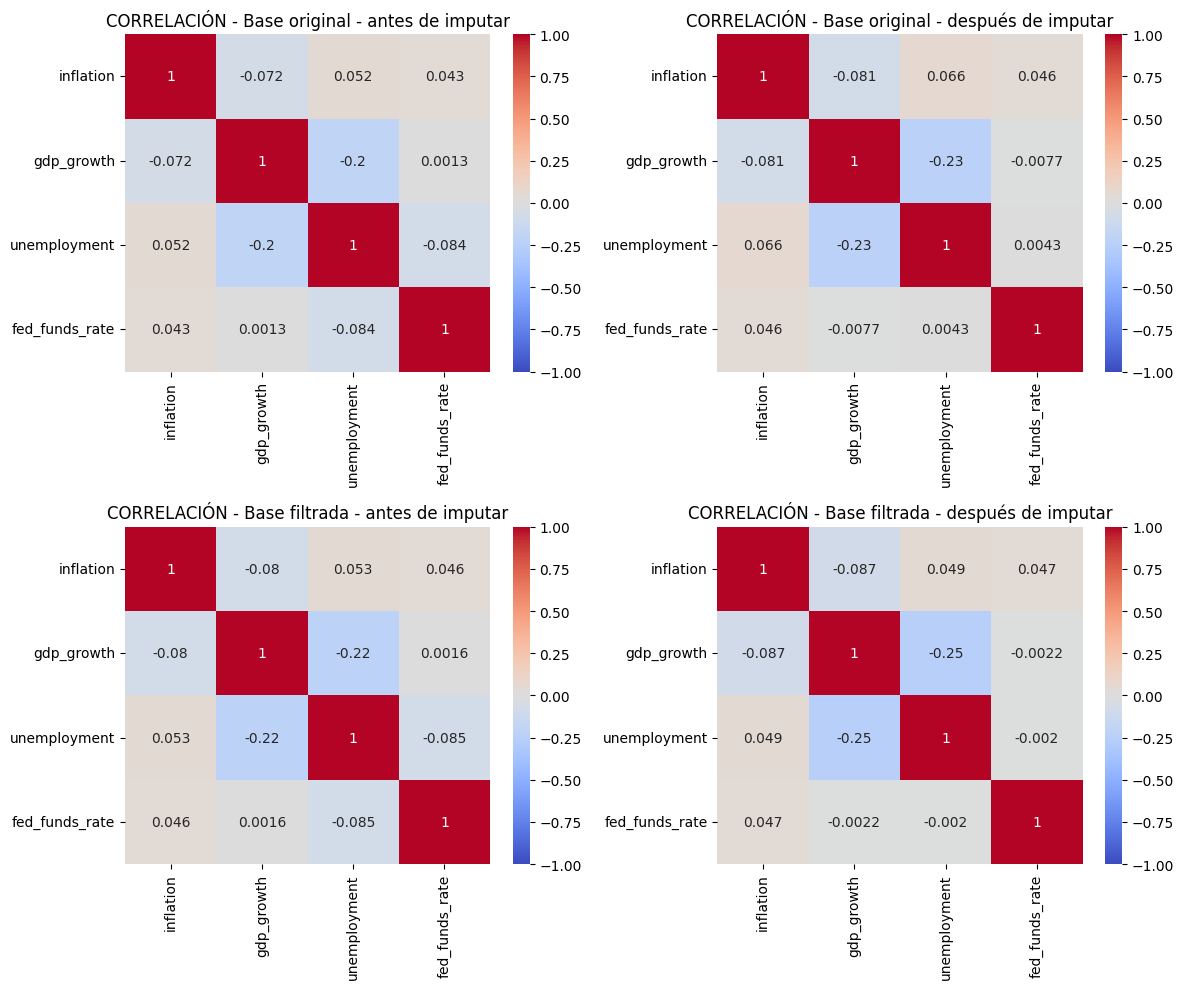

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.heatmap(corr_orig_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0, 0])
axes[0, 0].set_title("CORRELACIÓN - Base original - antes de imputar")

sns.heatmap(corr_orig_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title("CORRELACIÓN - Base original - después de imputar")

sns.heatmap(corr_filt_before, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 0])
axes[1, 0].set_title("CORRELACIÓN - Base filtrada - antes de imputar")

sns.heatmap(corr_filt_after, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("CORRELACIÓN - Base filtrada - después de imputar")

plt.tight_layout()
plt.show()

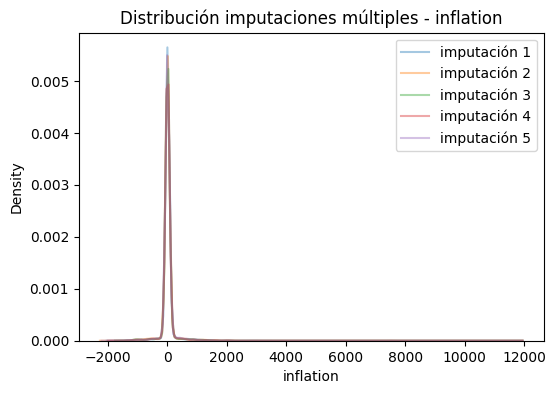

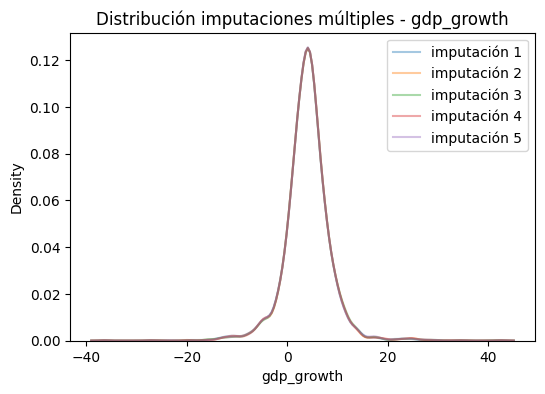

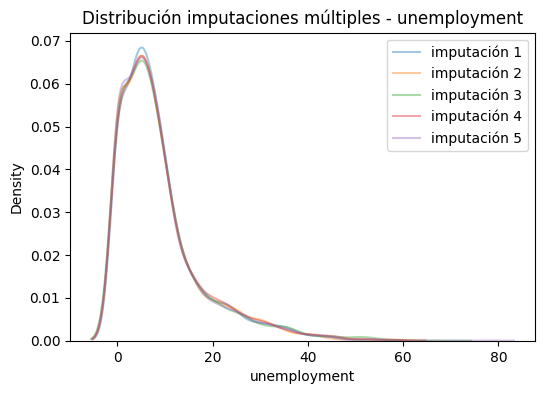

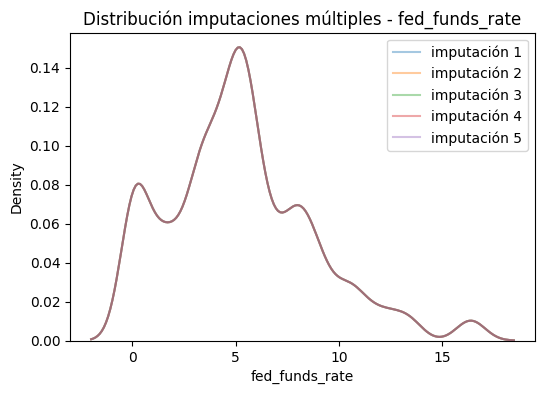

In [29]:
# variabilidad entre imputaciones múltiples

for var in study_vars:

    plt.figure(figsize=(6,4))

    for i, df_imp in enumerate(df_imputed_filt_list):
        sns.kdeplot(df_imp[var], label=f"imputación {i+1}", alpha=0.4)

    plt.title(f"Distribución imputaciones múltiples - {var}")
    plt.legend()
    plt.show()

In [28]:
outliers_original_table = outliers_por_pais(df, study_vars=study_vars)
print("OUTLIERS POR PAÍS - BASE ORIGINAL")
print(outliers_original_table)

OUTLIERS POR PAÍS - BASE ORIGINAL
    iso3  n_outliers  n_obs        variable  pct_outliers
0    AGO           1     56  fed_funds_rate      1.785714
1    AGO           7     56      gdp_growth     12.500000
2    AGO          14     56       inflation     25.000000
3    AGO           2     56    unemployment      3.571429
4    ARG           1     56  fed_funds_rate      1.785714
..   ...         ...    ...             ...           ...
161  ZMB           3     56      gdp_growth      5.357143
162  ZMB          13     56       inflation     23.214286
163  ZMB           2     56    unemployment      3.571429
164  ZWE           1     56  fed_funds_rate      1.785714
165  ZWE          14     56      gdp_growth     25.000000

[166 rows x 5 columns]


In [29]:
outliers_filtered_table = outliers_por_pais(df_filtered, study_vars=study_vars)
print("OUTLIERS POR PAÍS - BASE FILTRADA")
print(outliers_filtered_table)

OUTLIERS POR PAÍS - BASE FILTRADA
    iso3  n_outliers  n_obs        variable  pct_outliers
0    ARG           1     56  fed_funds_rate      1.785714
1    ARG           8     56      gdp_growth     14.285714
2    ARG           3     56    unemployment      5.357143
3    AUS           1     56  fed_funds_rate      1.785714
4    AUT           1     56  fed_funds_rate      1.785714
..   ...         ...    ...             ...           ...
145  ZAF          18     56    unemployment     32.142857
146  ZMB           1     56  fed_funds_rate      1.785714
147  ZMB           4     56      gdp_growth      7.142857
148  ZMB          13     56       inflation     23.214286
149  ZMB           2     56    unemployment      3.571429

[150 rows x 5 columns]
